# Air Quality Analysis: Prague Metropolitan Area
## Project Deliverable Pipeline & Exploratory Data Analysis (EDA)

This document serves as the data architecture record and exploratory core accompanying the interactive air quality dashboard. The objective of this analysis is to parse, visualize, and explore the underlying temporal and spatial relationships between urban atmospheric pollutants and microclimate meteorological conditions.

### Contents:
1. **Data Architecture Overview:** Quantify structural dimensions, evaluate dataset completeness, and isolate missing data flags.
2. **Frequency Spectrum Analysis:** Map structural distribution density variations across target pollutants ($PM_{10}$, $NO_2$, $NO_x$) and primary weather indicators.
3. **Anthropogenic Chrono-Analysis:** Uncover weekly human behavioral cycles by plotting hourly concentration patterns across the tracking time horizon.
4. **Geographic Sensor Network Alignment:** Evaluate the spatial proximity matrix mapping air quality observation centers to their nearest co-located weather station grids.

---

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from shapely.geometry import LineString
import contextily as ctx

# Set plotting style 
plt.style.use('seaborn-v0_8-whitegrid') 
sns.set_context("notebook", font_scale=1.1)

# Load data
df = pd.read_csv("../data/processed/processed_data.csv")
df['startTime'] = pd.to_datetime(df['startTime'])

In [36]:
# Master dictionary mapping core parameters to standardized semantic names, plots, and colors
VARIABLE_MAP = {
    "air_PM10":  {"name": r"$PM_{10}$", "unit": "$\mu g/m^3$", "color": "#1E88E5", "limit": 50.0},
    "air_NO2":   {"name": r"$NO_2$",  "unit": "$\mu g/m^3$", "color": "#D81B60", "limit": 200.0},
    "air_NOx":   {"name": r"$NO_x$",  "unit": "$\mu g/m^3$", "color": "#8E24AA", "limit": 200.0},
    "weather_T": {"name": "Air Temperature", "unit": "°C", "color": "#FF8F00"},
    "weather_TMA": {"name": "Max Air Temperature", "unit": "°C", "color": "#E65100"},
    "weather_TMI": {"name": "Min Air Temperature", "unit": "°C", "color": "#F57C00"},
    "weather_F": {"name": "Wind Speed", "unit": "m/s", "color": "#4CAF50"},
    "weather_H": {"name": "Relative Humidity", "unit": "%", "color": "#00BCD4"},
    "weather_P": {"name": "Atmospheric Pressure", "unit": "hPa", "color": "#9C27B0"},
    "weather_SRA10M": {"name": "Precipitation", "unit": "mm", "color": "#3F51B5"}
}

# Explicit collections to prevent manual array re-declarations down-pipeline
target_cols = ["air_PM10", "air_NO2", "air_NOx"]
weather_cols = ["weather_T", "weather_TMA", "weather_TMI", "weather_F", "weather_H", "weather_P", "weather_SRA10M"]
analysis_cols = target_cols + ["weather_T", "weather_F", "weather_H", "weather_P", "weather_SRA10M"]

# Synchronize Seaborn's global plotting engine
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "font.family": "sans-serif",
    "axes.edgecolor": "#CCCCCC",
    "axes.linewidth": 0.8,
    "grid.color": "#EAEAEA"
})

<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:4: SyntaxWarning: invalid escape sequence '\m'
<>:5: SyntaxWarning: invalid escape sequence '\m'
<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:4: SyntaxWarning: invalid escape sequence '\m'
<>:5: SyntaxWarning: invalid escape sequence '\m'
/var/folders/mx/y1mmdwj15w72tfrq1ygjnpj80000gn/T/ipykernel_43609/1854235146.py:3: SyntaxWarning: invalid escape sequence '\m'
  "air_PM10":  {"name": r"$PM_{10}$", "unit": "$\mu g/m^3$", "color": "#1E88E5", "limit": 50.0},
/var/folders/mx/y1mmdwj15w72tfrq1ygjnpj80000gn/T/ipykernel_43609/1854235146.py:4: SyntaxWarning: invalid escape sequence '\m'
  "air_NO2":   {"name": r"$NO_2$",  "unit": "$\mu g/m^3$", "color": "#D81B60", "limit": 200.0},
/var/folders/mx/y1mmdwj15w72tfrq1ygjnpj80000gn/T/ipykernel_43609/1854235146.py:5: SyntaxWarning: invalid escape sequence '\m'
  "air_NOx":   {"name": r"$NO_x$",  "unit": "$\mu g/m^3$", "color": "#8E24AA", "limit": 200.0},


In [37]:
num_rows, num_cols = df.shape
min_date = df['startTime'].min()
max_date = df['startTime'].max()
time_span = max_date - min_date
unique_stations = df['air_station_name'].unique()

print(f"==================================================")
print(f"          DATA ARCHITECTURE SUMMARY               ")
print(f"==================================================")
print(f"• Total Observations (Rows)          : {num_rows:,}")
print(f"• Feature & Attribute Schema Space   : {num_cols}")
print(f"• Baseline Temporal Window Boundary  : {min_date.date()} to {max_date.date()}")
print(f"• Complete Tracking Horizon Depth    : {time_span.days} days")
print(f"• Active Air Stations Quantified     : {len(unique_stations)}")
for s in unique_stations:
    print(f"   --> {s}")
print(f"==================================================")

print("\nMissing Values:")
missing_summary = df[analysis_cols].isnull().sum()
print(missing_summary)

          DATA ARCHITECTURE SUMMARY               
• Total Observations (Rows)          : 69,776
• Feature & Attribute Schema Space   : 56
• Baseline Temporal Window Boundary  : 2025-01-01 to 2025-12-31
• Complete Tracking Horizon Depth    : 364 days
• Active Air Stations Quantified     : 8
   --> Praha 1-n. Republiky
   --> Praha 10-Vršovice
   --> Praha 2-Legerova (hot spot)
   --> Praha 2-Riegrovy sady
   --> Praha 4-Libuš
   --> Praha 7-Holešovice
   --> Praha 8-Karlín
   --> Praha 9-Vysočany

Missing Values:
air_PM10          1095
air_NO2           4062
air_NOx           4155
weather_T          717
weather_F          717
weather_H          717
weather_P          717
weather_SRA10M     717
dtype: int64


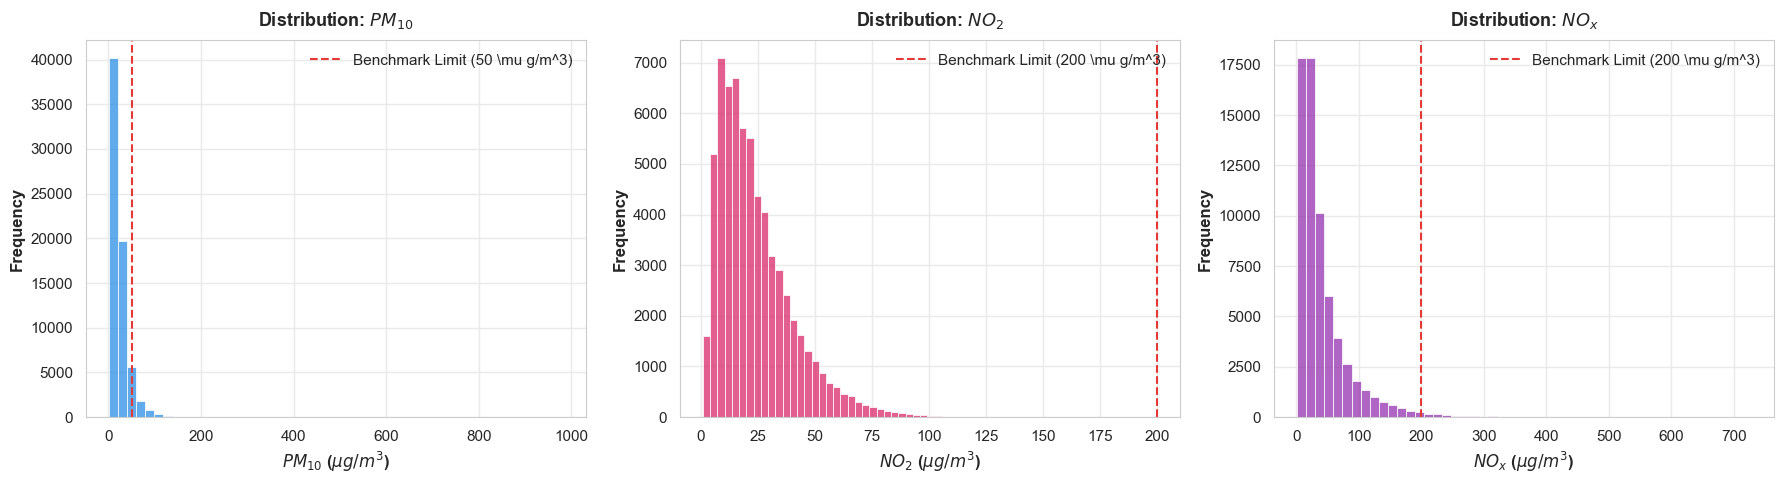

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for idx, col in enumerate(target_cols):
    meta = VARIABLE_MAP[col]
    sns.histplot(df[col].dropna(), bins=50, ax=axes[idx], color=meta["color"], alpha=0.7)
    axes[idx].axvline(meta["limit"], color='#E53935', linestyle='--', linewidth=1.5, 
                      label=f"Benchmark Limit ({int(meta['limit'])} {meta['unit'].replace('$', '')})")
    axes[idx].set_title(f"Distribution: {meta['name']}", fontsize=13, fontweight='bold', pad=10)
    axes[idx].set_xlabel(f"{meta['name']} ({meta['unit']})", fontweight='semibold')
    axes[idx].set_ylabel("Frequency", fontweight='semibold')
    axes[idx].legend(loc="upper right")

plt.tight_layout()
plt.show()

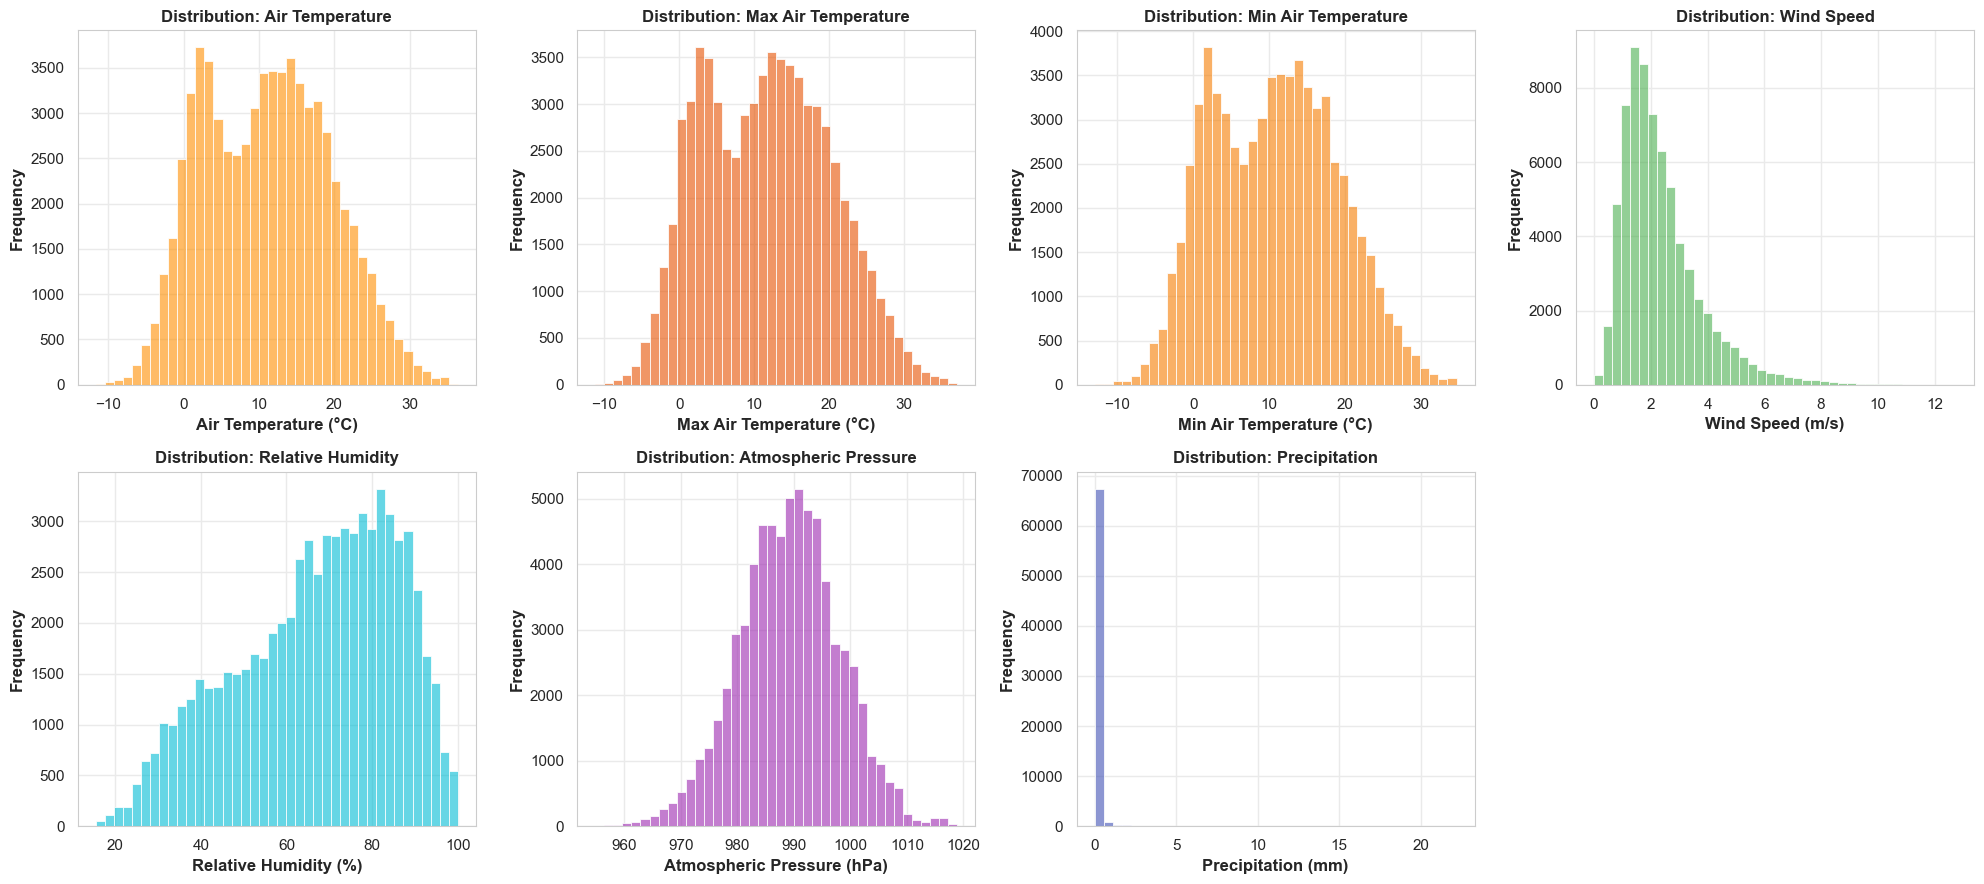

In [39]:
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()

for idx, col in enumerate(weather_cols):
    meta = VARIABLE_MAP[col]
    if col in df.columns:
        sns.histplot(df[col].dropna(), bins=40, ax=axes[idx], color=meta["color"], alpha=0.6)
        axes[idx].set_title(f"Distribution: {meta['name']}", fontsize=12, fontweight='bold')
        axes[idx].set_xlabel(f"{meta['name']} ({meta['unit']})", fontweight='semibold')
        axes[idx].set_ylabel("Frequency", fontweight='semibold')
    else:
        axes[idx].axis('off')

# Hide the final leftover structural axis tile in the grid template loop
if len(weather_cols) < len(axes):
    axes[-1].axis('off')

plt.tight_layout()
plt.show()

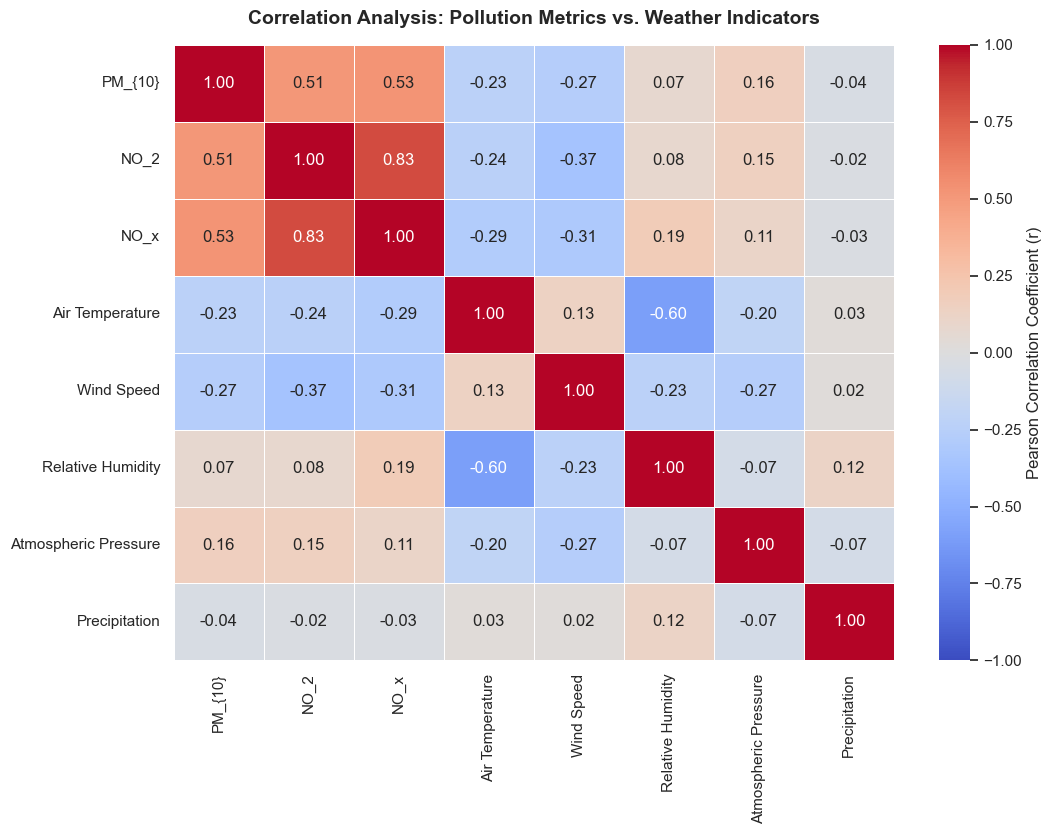

In [40]:
# --- Station-by-Station Outlier & Range Profile ---
plt.figure(figsize=(11, 8.5))

# Compute correlation matrix and map display titles from technical columns
corr_matrix = df[analysis_cols].corr()
display_labels = [VARIABLE_MAP[col]["name"].replace("$", "") for col in analysis_cols]
corr_matrix.columns = display_labels
corr_matrix.index = display_labels

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1,
            cbar_kws={"label": "Pearson Correlation Coefficient (r)"})
plt.title('Correlation Analysis: Pollution Metrics vs. Weather Indicators', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

/var/folders/mx/y1mmdwj15w72tfrq1ygjnpj80000gn/T/ipykernel_43609/3195195804.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')


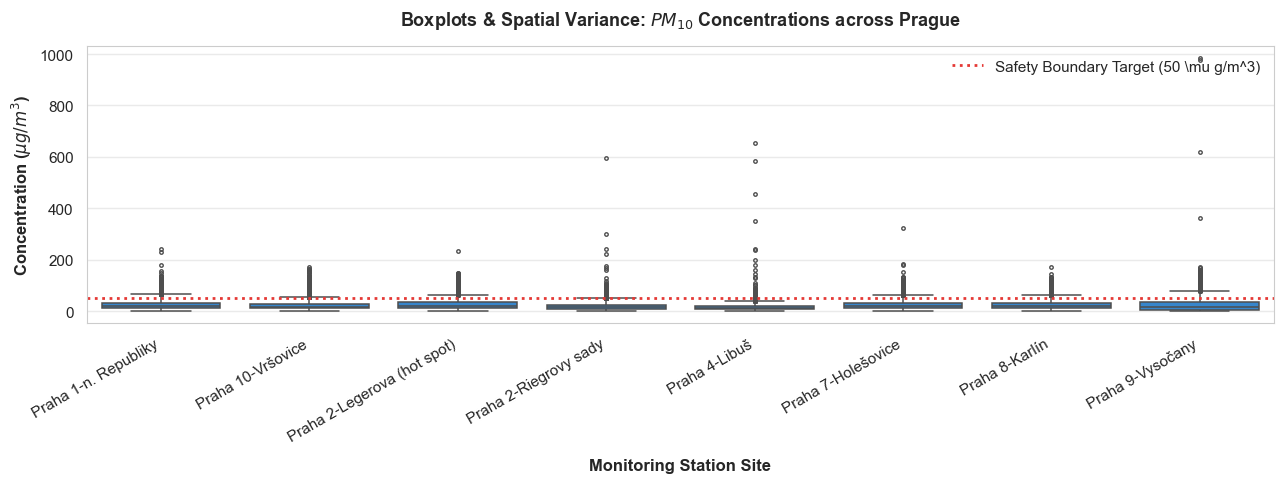

/var/folders/mx/y1mmdwj15w72tfrq1ygjnpj80000gn/T/ipykernel_43609/3195195804.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')


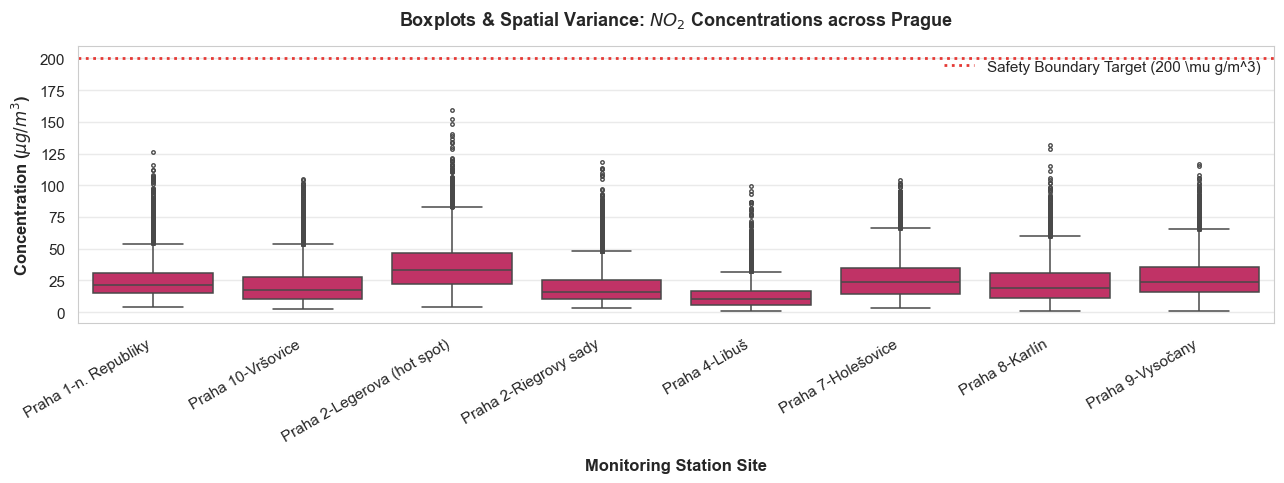

/var/folders/mx/y1mmdwj15w72tfrq1ygjnpj80000gn/T/ipykernel_43609/3195195804.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')


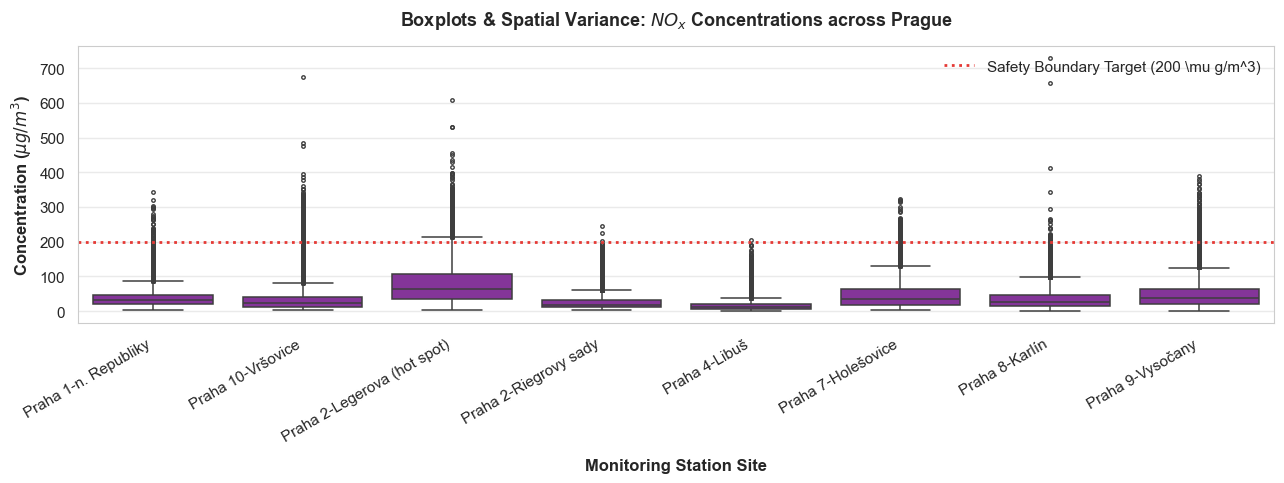

In [41]:
# --- Meteorological Attribute Spectrum Analysis ---

for col in target_cols:
    meta = VARIABLE_MAP[col]
    fig, ax = plt.subplots(figsize=(13, 5))
    
    sns.boxplot(
        data=df, 
        x="air_station_name", 
        y=col, 
        ax=ax, 
        color=meta["color"],
        fliersize=2.5,
        linewidth=1.1
    )
    
    ax.axhline(y=meta["limit"], color='#E53935', linestyle=':', linewidth=2, 
               label=f"Safety Boundary Target ({int(meta['limit'])} {meta['unit'].replace('$', '')})")
    
    ax.set_title(f"Boxplots & Spatial Variance: {meta['name']} Concentrations across Prague", fontsize=13, fontweight='bold', pad=15)
    ax.set_xlabel("Monitoring Station Site", fontweight='bold', labelpad=10)
    ax.set_ylabel(f"Concentration ({meta['unit']})", fontweight='bold')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
    ax.legend(loc="upper right")
    
    plt.tight_layout()
    plt.show()

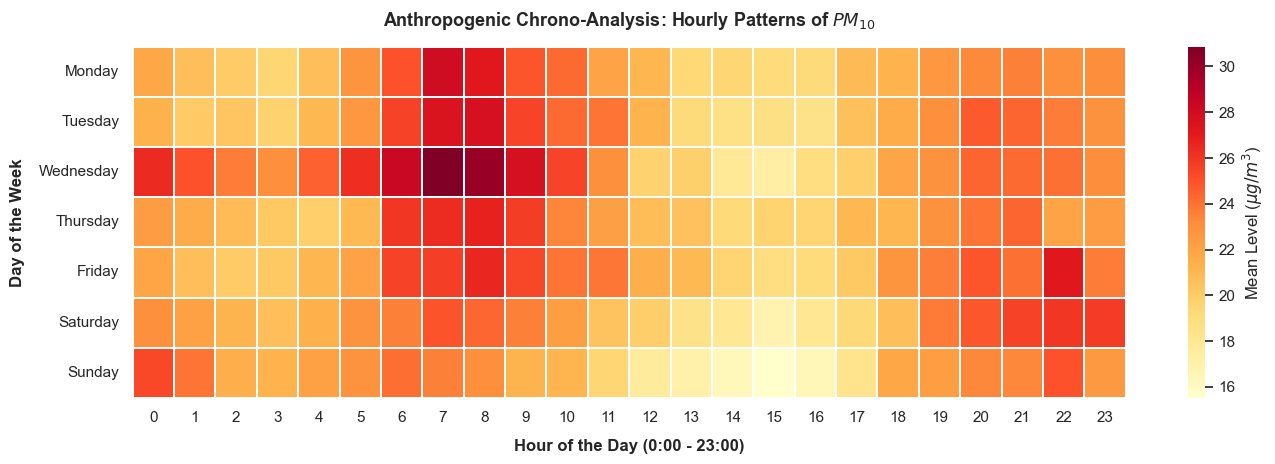

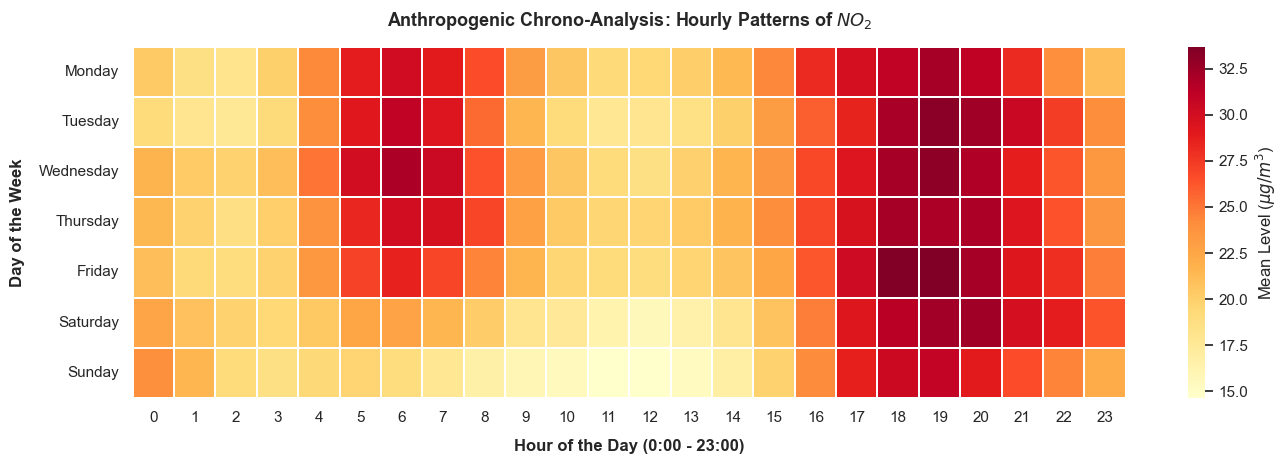

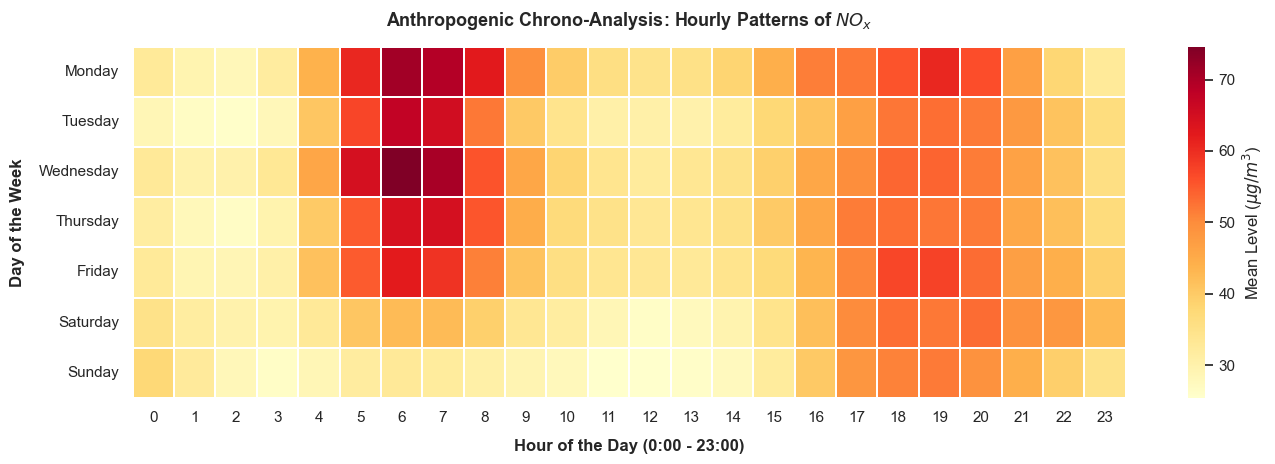

In [42]:
# --- Weekly Human Behavioral Heatmap Matrices ---
# Dynamic time extraction calculations
df['hour'] = df['startTime'].dt.hour
df['dayofweek'] = df['startTime'].dt.dayofweek
day_labels = {0: "Monday", 1: "Tuesday", 2: "Wednesday", 3: "Thursday", 4: "Friday", 5: "Saturday", 6: "Sunday"}

for col in target_cols:
    meta = VARIABLE_MAP[col]
    
    # Calculate means grouped dynamically by hour and weekday profile mappings
    temporal_agg = df.groupby(['dayofweek', 'hour'])[col].mean().reset_index()
    pivot_table = temporal_agg.pivot(index="dayofweek", columns="hour", values=col)
    pivot_table.index = pivot_table.index.map(day_labels)
    
    plt.figure(figsize=(14, 4.8))
    sns.heatmap(
        pivot_table,
        cmap="YlOrRd",
        cbar_kws={"label": f"Mean Level ({meta['unit']})"},
        linewidths=0.2
    )
    
    plt.title(f"Anthropogenic Chrono-Analysis: Hourly Patterns of {meta['name']}", fontsize=13, fontweight='bold', pad=15)
    plt.xlabel("Hour of the Day (0:00 - 23:00)", fontweight='bold', labelpad=10)
    plt.ylabel("Day of the Week", fontweight='bold', labelpad=10)
    plt.yticks(rotation=0)
    
    plt.tight_layout()
    plt.show()

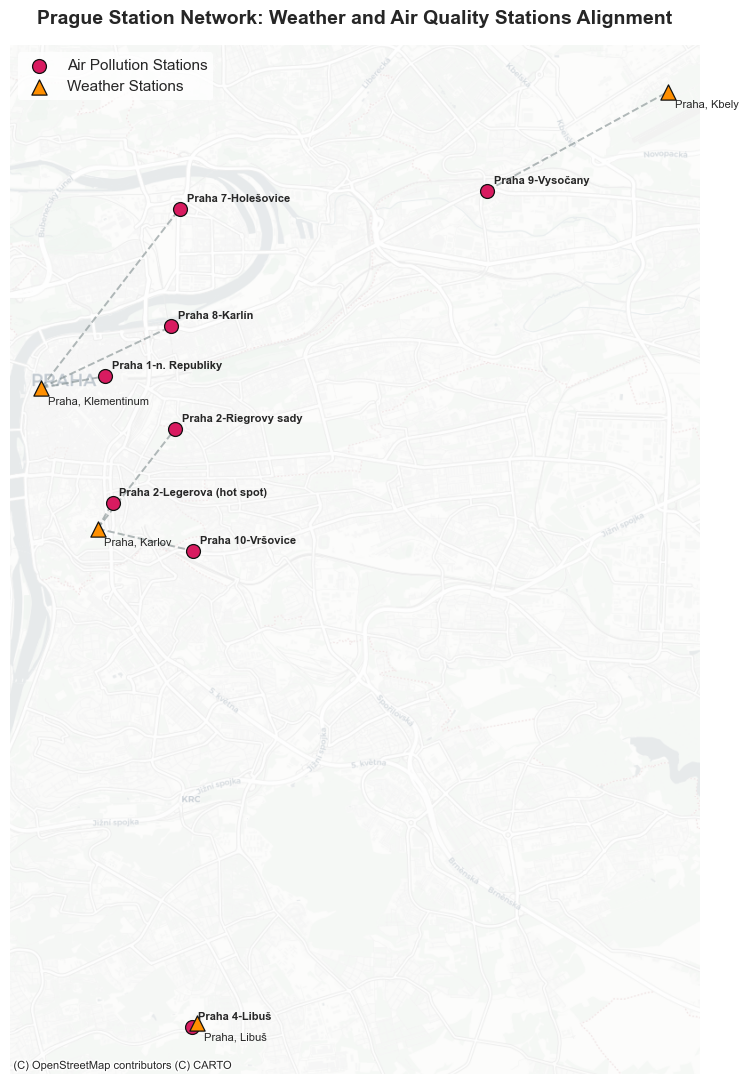

In [44]:
coord_cols = ["weather_lat", "weather_lon", "air_lat", "air_lon"]
df[coord_cols] = df[coord_cols].apply(pd.to_numeric, errors="coerce")

weather_stations = df[["weather_station_name", "weather_lat", "weather_lon"]].dropna().drop_duplicates().copy()
air_stations = df[["air_station_name", "air_lat", "air_lon"]].dropna().drop_duplicates().copy()
station_pairs = df[["air_station_name", "air_lat", "air_lon", "weather_station_name", "weather_lat", "weather_lon"]].dropna().drop_duplicates().copy()

# Initialize geographic structures (WGS84 Coordinate Space)
gdf_weather = gpd.GeoDataFrame(weather_stations, geometry=gpd.points_from_xy(weather_stations["weather_lon"], weather_stations["weather_lat"]), crs="EPSG:4326")
gdf_air = gpd.GeoDataFrame(air_stations, geometry=gpd.points_from_xy(air_stations["air_lon"], air_stations["air_lat"]), crs="EPSG:4326")

pair_lines = [
    {
        "air_station": r["air_station_name"],
        "weather_station": r["weather_station_name"],
        "geometry": LineString([(r["air_lon"], r["air_lat"]), (r["weather_lon"], r["weather_lat"])])
    } for _, r in station_pairs.iterrows()
]
gdf_pairs = gpd.GeoDataFrame(pair_lines, crs="EPSG:4326")

# Reproject spatial systems into Web Mercator metric projection for standard basemaps
gdf_weather = gdf_weather.to_crs(epsg=3857)
gdf_air = gdf_air.to_crs(epsg=3857)
gdf_pairs = gdf_pairs.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(11, 11))

# Vector Layers
gdf_pairs.plot(ax=ax, linewidth=1.4, alpha=0.6, color="#7F8C8D", linestyle="--", zorder=1)
gdf_air.plot(ax=ax, markersize=100, marker="o", label="Air Pollution Stations", color="#D81B60", alpha=1.0, edgecolor="#111111", linewidth=0.9, zorder=3)
gdf_weather.plot(ax=ax, markersize=120, marker="^", label="Weather Stations", color="#FF8F00", alpha=1.0, edgecolor="#111111", linewidth=0.9, zorder=4)

# Static Annotation Offsets
for _, row in gdf_air.iterrows():
    ax.annotate(row["air_station_name"], xy=(row.geometry.x, row.geometry.y), xytext=(5, 5), textcoords="offset points", fontsize=8, fontweight="bold", zorder=5)
for _, row in gdf_weather.iterrows():
    ax.annotate(row["weather_station_name"], xy=(row.geometry.x, row.geometry.y), xytext=(5, -12), textcoords="offset points", fontsize=8, zorder=5)

# Append clean vector background map canvas layers
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, alpha=0.55)

ax.set_title("Prague Station Network: Weather and Air Quality Stations Alignment", fontsize=14, fontweight='bold', pad=15)
ax.set_axis_off()
ax.legend(loc="upper left", frameon=True, facecolor="white", edgecolor="none")

plt.tight_layout()
plt.show()